In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

BASE_DIR = Path.cwd().parent if Path.cwd().name == "machine_learning" else Path.cwd()
RAW_DIR = BASE_DIR / "web_scraping" / "raw"
ML_DIR = BASE_DIR / "machine_learning"
WEB_DIR = BASE_DIR / "web"

season_weights = {
    "s2425-laliga-players.csv": 0.4,
    "s2324-laliga-players.csv": 0.3,
    "s2223-laliga-players.csv": 0.2,
    "s2122-laliga-players.csv": 0.1
}

try:
    df_activos = pd.read_csv(ML_DIR / "jugadores_2627.csv") 
    jugadores_activos = set(df_activos["player_name"].unique())
    print(f"Total de jugadores activos cargados: {len(jugadores_activos)}")
except FileNotFoundError:
    print("Error: No se encontró jugadores_2627.csv.")
    jugadores_activos = set()

Total de jugadores activos cargados: 464


In [2]:
df_list = []
stats_cols = ["minutes_played", "goals", "assists", "yellow_cards", "red_cards"]

for filename, weight in season_weights.items():
    try:
        temp_df = pd.read_csv(RAW_DIR / filename)
        
        temp_df = temp_df[temp_df["player_name"].isin(jugadores_activos)].copy()
        
        for col in stats_cols:
            if col in temp_df.columns:
                temp_df[col] = temp_df[col] * weight
                
        df_list.append(temp_df)
        print(f"{filename} procesado correctamente con peso {weight}.")
    except FileNotFoundError:
        print(f"Advertencia: No se encontró el archivo {filename}")

if df_list:
    data = pd.concat(df_list, ignore_index=True)
    
    agg_data = data.groupby("player_name").agg({
        "minutes_played": "sum",
        "goals": "sum",
        "assists": "sum",
        "yellow_cards": "sum",
        "red_cards": "sum",
        "team": "first", 
        "position": "first",
    }).reset_index()

    agg_data = agg_data[agg_data["minutes_played"] > 30].copy()
    print(f"Datos agregados. Jugadores finales a evaluar: {len(agg_data)}")
else:
    raise ValueError("Error Crítico: No se pudo cargar ningún archivo de temporada. Revisa las rutas en RAW_DIR.")

s2425-laliga-players.csv procesado correctamente con peso 0.4.
s2324-laliga-players.csv procesado correctamente con peso 0.3.
s2223-laliga-players.csv procesado correctamente con peso 0.2.
s2122-laliga-players.csv procesado correctamente con peso 0.1.
Datos agregados. Jugadores finales a evaluar: 287


In [3]:
agg_data["base_score"] = (
    agg_data["goals"] * 5 +
    agg_data["assists"] * 3 -
    agg_data["yellow_cards"] -
    agg_data["red_cards"] * 3
)

agg_data["efficiency"] = agg_data["base_score"] / (agg_data["minutes_played"] / 90)
agg_data["mvp_score"] = agg_data["base_score"] * 0.7 + agg_data["efficiency"] * 0.3

max_score = agg_data["mvp_score"].max()
agg_data["mvp_percentage"] = (agg_data["mvp_score"] / max_score) * 100

top10 = agg_data.sort_values("mvp_percentage", ascending=False).head(10)
top10.to_csv(WEB_DIR / "top10_predictions.csv", index=False)
top10[["player_name", "team", "position", "mvp_percentage"]]

,player_name,team,position,mvp_percentage
321,Vinícius Júnior,Real Madrid,LW,100.000000
131,Iago Aspas,Celta Vigo,AM,94.688726
120,Gerard Moreno,Villarreal,FW,70.399775
184,Jude Bellingham,Real Madrid,LM,70.301963
34,Ante Budimir,Osasuna,FW,70.083703
53,Borja Mayoral,Getafe,FW,69.201037
123,Gorka Guruzeta,Athletic Club,FW,68.514783
145,Iñaki Williams,Athletic Club,RW,66.511254
279,Rodrygo Silva de Goes,Real Madrid,RW,66.496725
125,Hugo Duro,Valencia,FW,55.886572


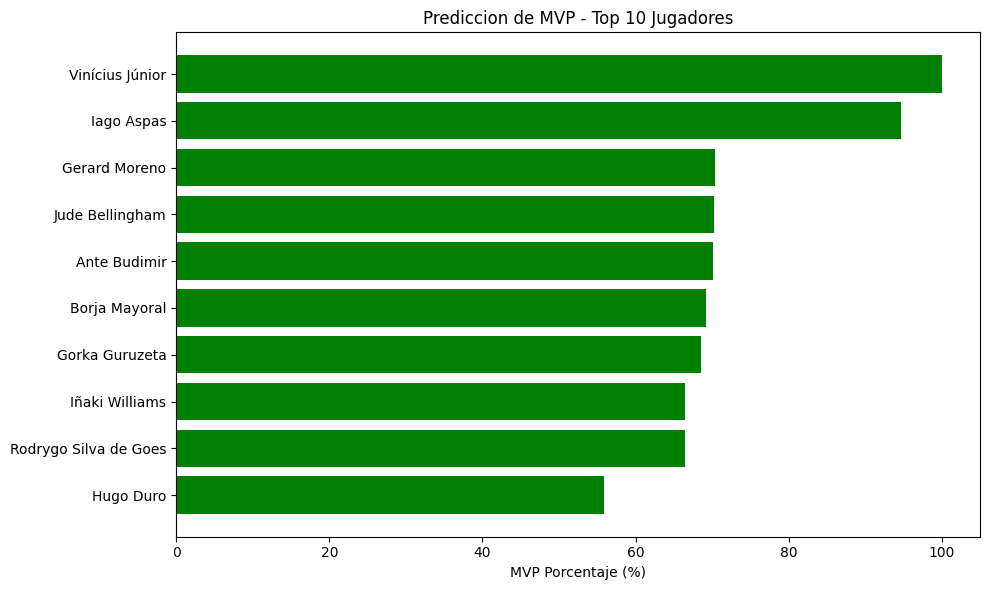

In [4]:
plt.figure(figsize=(10, 6))
plt.barh(top10["player_name"], top10["mvp_percentage"], color="green")
plt.xlabel("MVP Porcentaje (%)")
plt.title("Prediccion de MVP - Top 10 Jugadores")
plt.gca().invert_yaxis()
plt.tight_layout()
#plt.savefig(WEB_DIR / "mvp_top10_ranking.png")
plt.show()